In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import wooldridge as woo
import pandas as pd
import wooldridge as woo

### Part C

In [ ]:
def generate_data(S, N, beta, sigma_sq, rho):
    """Generate S simulations of N observations each"""

    # Covariance matrix for bivariate normal
    # Var(X₁) = Var(X₂) = 1, Cov(X₁, X₂) = ρ
    mean = [0, 0]
    cov = [[1, rho],
           [rho, 1]]
    
    Y = np.zeros((S, N))
    X = np.zeros((S, N, len(beta)))
    
    for s in range(S):
        # Generate bivariate normal random variables
        x_bvn = np.random.multivariate_normal(mean, cov, size=N)
        
        # Construct design matrix with intercept
        x = np.column_stack([np.ones(N), x_bvn])
        
        # Generate error term: u ~ N(0, σ²)
        sigma = np.sqrt(sigma_sq)
        u = np.random.normal(0, sigma, N)
        
        # Generate y = X'β + u
        y = x @ beta + u

        Y[s] = y
        X[s] = x      # Stores N observations for len(beta) parameters in simulation s
    
    return Y, X


### Part D

In [122]:
# Create histograms
def plot_betas(beta, beta_hats):
    fig, axes = plt.subplots(1, len(beta), figsize=(15, 4))
    param_names = ['β₀ (Intercept)', 'β₁', 'β₂']

    beta_mean = beta_hats.mean(axis=0)
    beta_std = beta_hats.std(axis=0)

    for i in range(len(beta)):
        ax = axes[i]
        
        # Histogram
        ax.hist(beta_hats[:, i], bins=20, density=True, alpha=0.7, 
                edgecolor='black', label='Estimated β̂')
        
        # True value (vertical line)
        ax.axvline(beta[i], color='red', linestyle='--', 
                linewidth=2, label=f'True β = {beta[i]}')
        
        # Mean of estimates (vertical line)
        ax.axvline(beta_mean[i], color='green', linestyle='-', 
                linewidth=2, label=f'Mean β̂ = {beta_mean[i]:.3f}')
        
        # Overlay normal distribution
        x_range = np.linspace(beta_hats[:, i].min(), beta_hats[:, i].max(), 100)
        from scipy import stats
        ax.plot(x_range, stats.norm.pdf(x_range, beta_mean[i], beta_std[i]), 
                'b-', linewidth=2, alpha=0.7, label='Normal fit')
        
        ax.set_xlabel(param_names[i])
        ax.set_ylabel('Density')
        ax.set_title(f'Distribution of {param_names[i]}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('monte_carlo_results.png', dpi=300, bbox_inches='tight')
    plt.show()

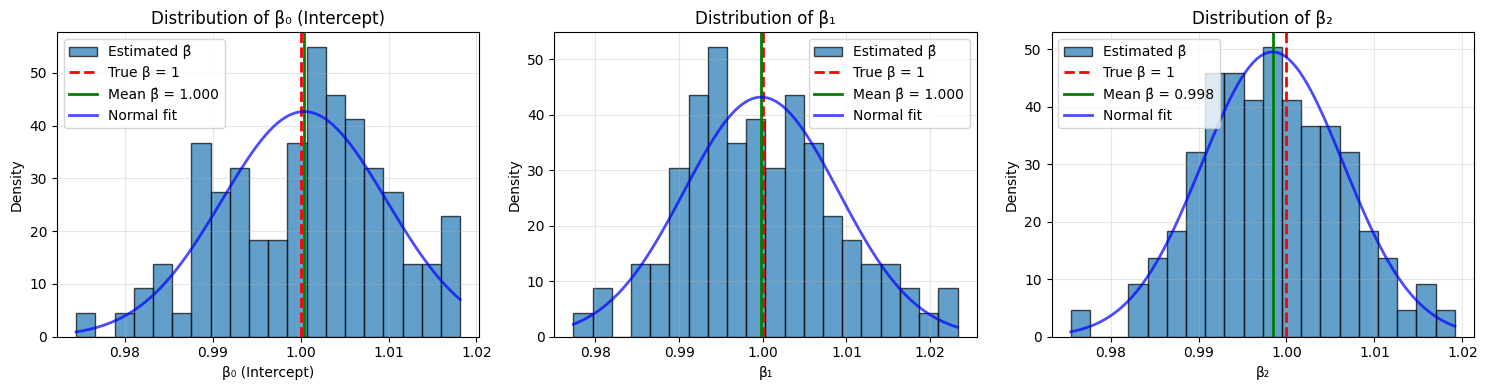

In [123]:
# Generate new data

N = 10000
S = 100
beta = [1, 1, 1]
sigma_sq = 1
rho = 0

# Y, X, beta_hats = generate_data(S, N, beta, sigma_sq, rho)

Y, X = generate_data(S, N, beta, sigma_sq, rho)

beta_hats = np.zeros((S, 3))
for s in range(S):
    beta_hats[s] = sm.OLS(Y[s], X[s]).fit().params

plot_betas(beta, beta_hats)

### Part E

In [124]:
# Filter and plot data function

def drop_filter(drop_value, X, Y, beta):
    # Reset for each drop value
    Y_filtered_temp = []
    X_filtered_temp = []
    beta_hats_filtered = np.zeros((S, 3))
    
    for s in range(S):
        keep = X[s, :, 2] <= drop_value
        
        Y_filtered_temp.append(Y[s, keep])
        X_filtered_temp.append(X[s, keep, :])

        beta_hats_filtered[s] = sm.OLS(Y_filtered_temp[s], X_filtered_temp[s]).fit().params

    # Store results
    beta_hats_filtered
    
    print(f'\n{"="*60}')
    print(f'Drop Value: {drop_value}')
    print(f'{"="*60}')
    plot_betas(beta, beta_hats_filtered)
    
    # Calculate differences from original (unfiltered) beta_hats
    diff = beta_hats_filtered - beta_hats

    print(f"Original β̂₀ mean: {beta_hats[:, 0].mean():.6f} | Filtered: {beta_hats_filtered[:, 0].mean():.6f} | Mean difference in β₀: {diff[:, 0].mean():.6f}")
    print(f"Original β̂₁ mean: {beta_hats[:, 1].mean():.6f} | Filtered: {beta_hats_filtered[:, 1].mean():.6f} | Mean difference in β₁: {diff[:, 1].mean():.6f}")
    print(f"Original β̂₂ mean: {beta_hats[:, 2].mean():.6f} | Filtered: {beta_hats_filtered[:, 2].mean():.6f} | Mean difference in β₂: {diff[:, 2].mean():.6f}")
    
    # Sample size info
    sample_sizes = [len(Y_filtered_temp[s]) for s in range(S)]
    print(f"\nAverage sample size after filtering: {np.mean(sample_sizes):.1f}")
    print(f"Percentage retained: {100 * np.mean(sample_sizes) / N:.1f}%")



Drop Value: 1.5


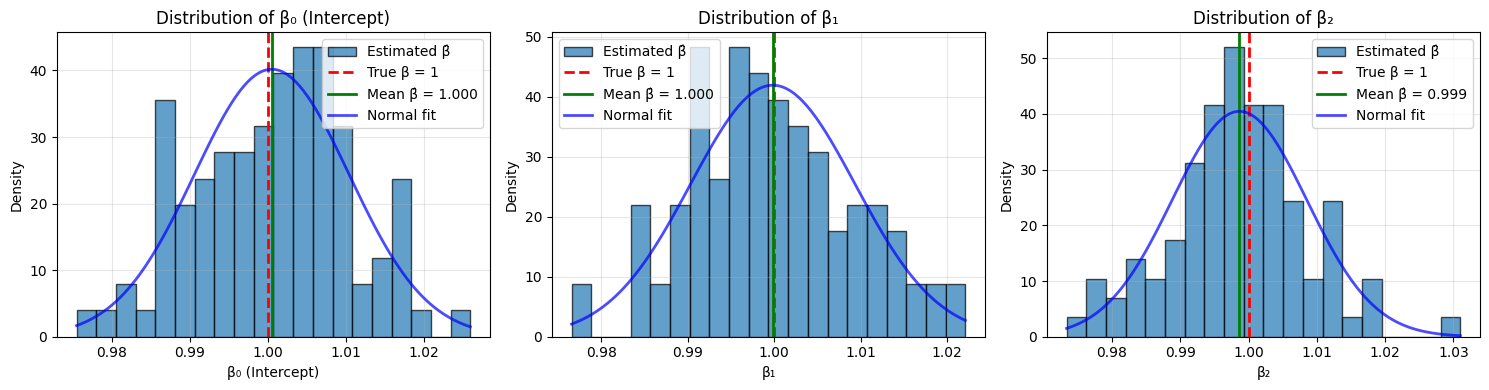

Original β̂₀ mean: 1.000404 | Filtered: 1.000492 | Mean difference in β₀: 0.000088
Original β̂₁ mean: 0.999812 | Filtered: 0.999835 | Mean difference in β₁: 0.000023
Original β̂₂ mean: 0.998424 | Filtered: 0.998678 | Mean difference in β₂: 0.000254

Average sample size after filtering: 9330.1
Percentage retained: 93.3%

Drop Value: 0.5


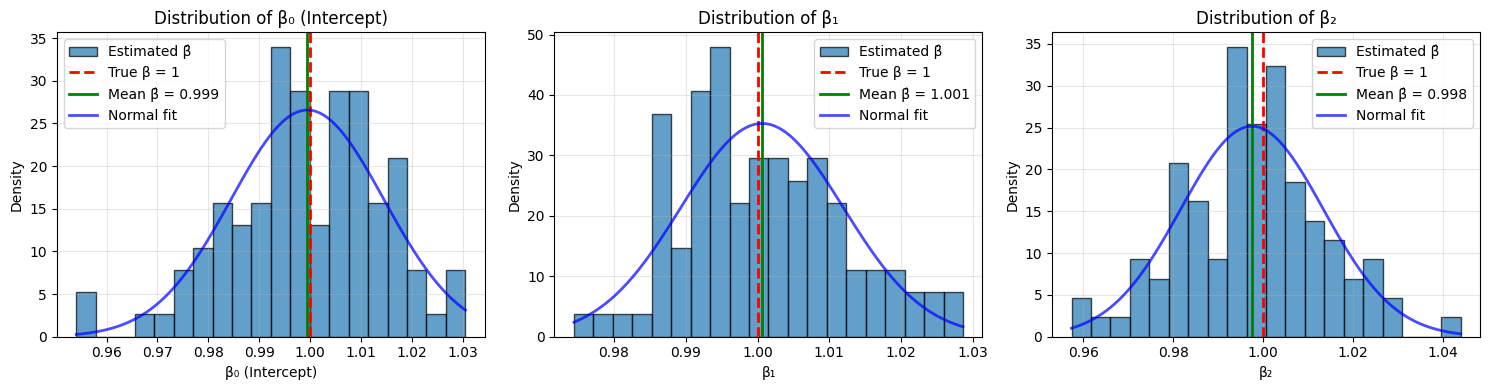

Original β̂₀ mean: 1.000404 | Filtered: 0.999496 | Mean difference in β₀: -0.000908
Original β̂₁ mean: 0.999812 | Filtered: 1.000632 | Mean difference in β₁: 0.000820
Original β̂₂ mean: 0.998424 | Filtered: 0.997513 | Mean difference in β₂: -0.000911

Average sample size after filtering: 6914.9
Percentage retained: 69.1%


In [125]:
# Filter observations from previously generated data

drop_values = [1.5, 0.5]

for i in range(len(drop_values)):
    drop_filter(drop_values[i], X, Y, beta)

The smaller drop value holds less information on the true value of the coefficient parameters, hence why more of the calculated mean values are further away from the true values.

However, an interesting observation is that despite such a large cutoff in the smaller drop value, the model is still able to calculate mean values that are surprisingly close to their true values. This motivates a hypothesis that observations where xi,3 > 0.5 might not be as important to retaining information on the data's behavior.

### Part F

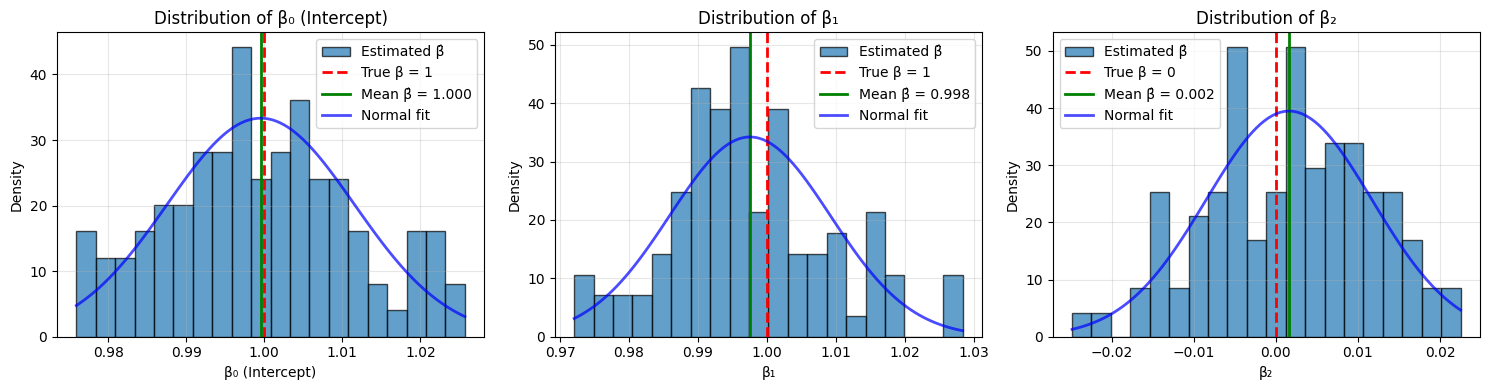

In [126]:
# Generate new data

N = 10000
S = 100
beta = [1, 1, 0]
sigma_sq = 1
rho = 0.5

Y, X = generate_data(S, N, beta, sigma_sq, rho)

beta_hats = np.zeros((S, 3))
for s in range(S):
    beta_hats[s] = sm.OLS(Y[s], X[s]).fit().params

plot_betas(beta, beta_hats)

### Part G


Drop Value: 1.5


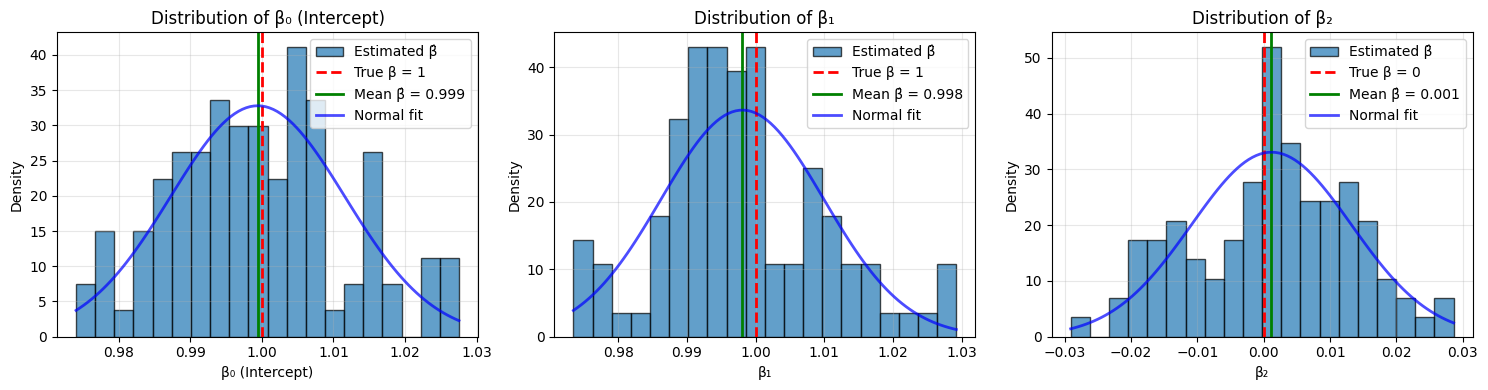

Original β̂₀ mean: 0.999549 | Filtered: 0.999423 | Mean difference in β₀: -0.000126
Original β̂₁ mean: 0.997545 | Filtered: 0.998082 | Mean difference in β₁: 0.000537
Original β̂₂ mean: 0.001604 | Filtered: 0.001156 | Mean difference in β₂: -0.000448

Average sample size after filtering: 9332.6
Percentage retained: 93.3%

Drop Value: 0.5


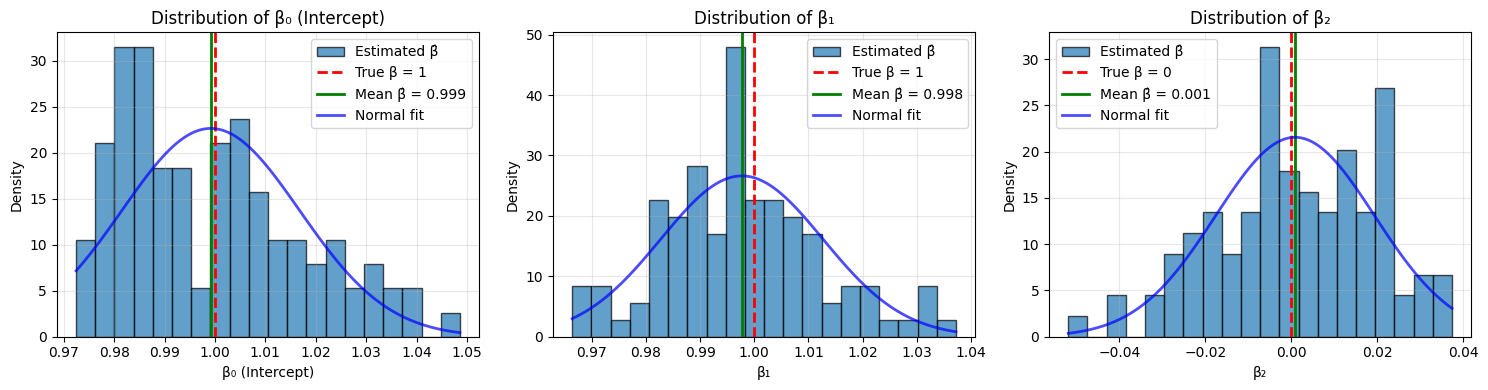

Original β̂₀ mean: 0.999549 | Filtered: 0.999161 | Mean difference in β₀: -0.000388
Original β̂₁ mean: 0.997545 | Filtered: 0.997706 | Mean difference in β₁: 0.000161
Original β̂₂ mean: 0.001604 | Filtered: 0.000887 | Mean difference in β₂: -0.000717

Average sample size after filtering: 6908.8
Percentage retained: 69.1%


In [127]:
# Filter observations from previously generated data

drop_values = [1.5, 0.5]

for i in range(len(drop_values)):
    drop_filter(drop_values[i], X, Y, beta)

### describe